In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import matplotlib.pyplot as plt
df=pd.read_csv('taxifare.csv')
df

,unique_id,amount,date_time_of_pickup,longitude_of_pickup,latitude_of_pickup,longitude_of_dropoff,latitude_of_dropoff,no_of_passenger
0,26:21.0,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1
1,52:16.0,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1
2,35:00.0,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2
3,30:42.0,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1
4,51:00.0,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1
...,...,...,...,...,...,...,...,...
49995,25:15.0,15.0,2013-06-12 23:25:15 UTC,-73.999973,40.748531,-74.016899,40.705993,1
49996,19:18.0,7.5,2015-06-22 17:19:18 UTC,-73.984756,40.768211,-73.987366,40.760597,1
49997,53:00.0,6.9,2011-01-30 04:53:00 UTC,-74.002698,40.739428,-73.998108,40.759483,1
49998,09:00.0,4.5,2012-11-06 07:09:00 UTC,-73.946062,40.777567,-73.953450,40.779687,2


In [47]:
df.info

<bound method DataFrame.info of       unique_id  amount      date_time_of_pickup  longitude_of_pickup  \
0       26:21.0     4.5  2009-06-15 17:26:21 UTC           -73.844311   
1       52:16.0    16.9  2010-01-05 16:52:16 UTC           -74.016048   
2       35:00.0     5.7  2011-08-18 00:35:00 UTC           -73.982738   
3       30:42.0     7.7  2012-04-21 04:30:42 UTC           -73.987130   
4       51:00.0     5.3  2010-03-09 07:51:00 UTC           -73.968095   
...         ...     ...                      ...                  ...   
49995   25:15.0    15.0  2013-06-12 23:25:15 UTC           -73.999973   
49996   19:18.0     7.5  2015-06-22 17:19:18 UTC           -73.984756   
49997   53:00.0     6.9  2011-01-30 04:53:00 UTC           -74.002698   
49998   09:00.0     4.5  2012-11-06 07:09:00 UTC           -73.946062   
49999   13:14.0    10.9  2010-01-13 08:13:14 UTC           -73.932603   

       latitude_of_pickup  longitude_of_dropoff  latitude_of_dropoff  \
0               40.

In [48]:
df.isnull().sum()

unique_id               0
amount                  0
date_time_of_pickup     0
longitude_of_pickup     0
latitude_of_pickup      0
longitude_of_dropoff    0
latitude_of_dropoff     0
no_of_passenger         0
dtype: int64

In [49]:
df.duplicated().sum()

np.int64(0)

In [50]:
df['date_time_of_pickup']=pd.to_datetime(df['date_time_of_pickup'])

In [51]:
df['hour_of_day']=df['date_time_of_pickup'].dt.hour
df['day_of_week']=df['date_time_of_pickup'].dt.dayofweek
df['month']=df['date_time_of_pickup'].dt.month
df

,unique_id,amount,date_time_of_pickup,longitude_of_pickup,latitude_of_pickup,longitude_of_dropoff,latitude_of_dropoff,no_of_passenger,hour_of_day,day_of_week,month
0,26:21.0,4.5,2009-06-15 17:26:21+00:00,-73.844311,40.721319,-73.841610,40.712278,1,17,0,6
1,52:16.0,16.9,2010-01-05 16:52:16+00:00,-74.016048,40.711303,-73.979268,40.782004,1,16,1,1
2,35:00.0,5.7,2011-08-18 00:35:00+00:00,-73.982738,40.761270,-73.991242,40.750562,2,0,3,8
3,30:42.0,7.7,2012-04-21 04:30:42+00:00,-73.987130,40.733143,-73.991567,40.758092,1,4,5,4
4,51:00.0,5.3,2010-03-09 07:51:00+00:00,-73.968095,40.768008,-73.956655,40.783762,1,7,1,3
...,...,...,...,...,...,...,...,...,...,...,...
49995,25:15.0,15.0,2013-06-12 23:25:15+00:00,-73.999973,40.748531,-74.016899,40.705993,1,23,2,6
49996,19:18.0,7.5,2015-06-22 17:19:18+00:00,-73.984756,40.768211,-73.987366,40.760597,1,17,0,6
49997,53:00.0,6.9,2011-01-30 04:53:00+00:00,-74.002698,40.739428,-73.998108,40.759483,1,4,6,1
49998,09:00.0,4.5,2012-11-06 07:09:00+00:00,-73.946062,40.777567,-73.953450,40.779687,2,7,1,11


In [52]:
q1= df['amount'].quantile(0.25)
q3 = df['amount'].quantile(0.75)
IQR = q3-q1

In [53]:
ul= q1+mean*1.5

NameError: name 'mean' is not defined

In [ ]:
encoder=LabelEncoder()
df['unique_id']=encoder.fit_transform(df['unique_id'])
df

,unique_id,amount,date_time_of_pickup,longitude_of_pickup,latitude_of_pickup,longitude_of_dropoff,latitude_of_dropoff,no_of_passenger,hour_of_day,day_of_week,month
0,1579,4.5,2009-06-15 17:26:21+00:00,-73.844311,40.721319,-73.841610,40.712278,1,17,0,6
1,3133,16.9,2010-01-05 16:52:16+00:00,-74.016048,40.711303,-73.979268,40.782004,1,16,1,1
2,2097,5.7,2011-08-18 00:35:00+00:00,-73.982738,40.761270,-73.991242,40.750562,2,0,3,8
3,1839,7.7,2012-04-21 04:30:42+00:00,-73.987130,40.733143,-73.991567,40.758092,1,4,5,4
4,3057,5.3,2010-03-09 07:51:00+00:00,-73.968095,40.768008,-73.956655,40.783762,1,7,1,3
...,...,...,...,...,...,...,...,...,...,...,...
49995,1513,15.0,2013-06-12 23:25:15+00:00,-73.999973,40.748531,-74.016899,40.705993,1,23,2,6
49996,1157,7.5,2015-06-22 17:19:18+00:00,-73.984756,40.768211,-73.987366,40.760597,1,17,0,6
49997,3177,6.9,2011-01-30 04:53:00+00:00,-74.002698,40.739428,-73.998108,40.759483,1,4,6,1
49998,540,4.5,2012-11-06 07:09:00+00:00,-73.946062,40.777567,-73.953450,40.779687,2,7,1,11


<Axes: xlabel='amount'>

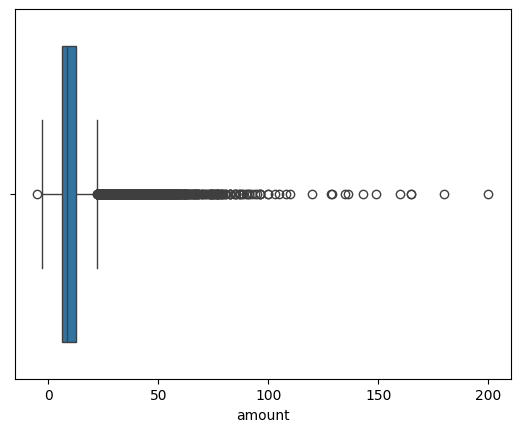

In [ ]:
sns.boxplot(x='amount',data=df)

<Axes: >

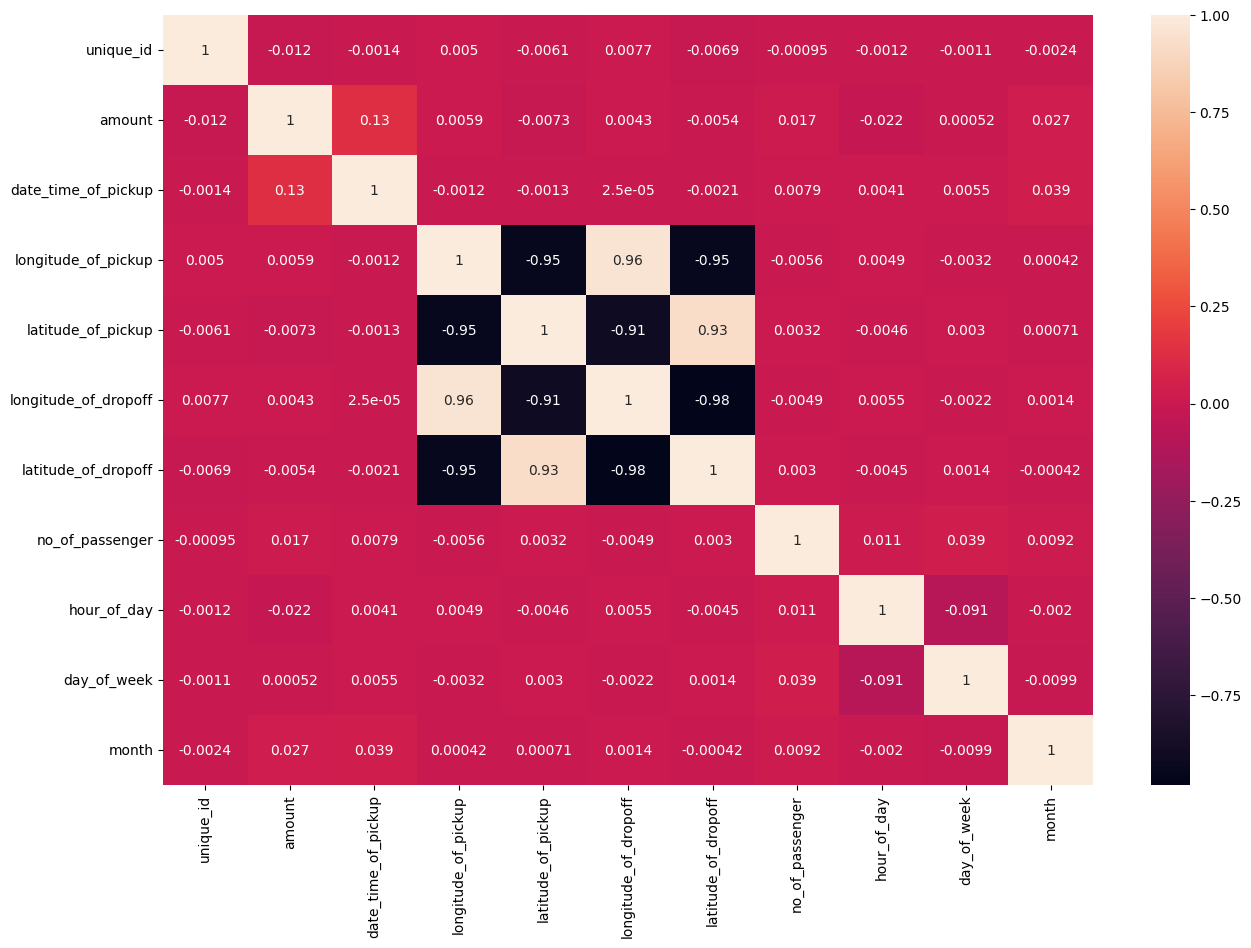

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),annot=True)

In [ ]:
x=df.drop(['amount','date_time_of_pickup'],axis=1)
x
y=df['amount']
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=42)


In [ ]:
from sklearn.linear_model import LinearRegression 
lin_reg=LinearRegression()
lin_reg.fit(x_train,y_train)

LinearRegression()

In [ ]:
print(lin_reg.coef_)
print(lin_reg.intercept_)


[-1.11518219e-04 -1.22175678e-03 -1.96187517e-02 -2.59761035e-02
 -3.23361950e-02  1.33527512e-01 -3.55786059e-02  2.98591133e-04
  7.60697786e-02]
11.458075360769703


In [ ]:
y_pred = lin_reg.predict(x_test)
mse = mean_squared_error(y_test , y_pred)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
mse,mae,r2




(92.85972513757271, 6.031724939931367, 0.0011959600534928727)

In [ ]:
dt=DecisionTreeRegressor()
dt.fit(x_train,y_train)
y_pred1=dt.predict(x_test)
train_score = dt.score(x_train,y_train) # train score
print(train_score)
mse1=mean_squared_error(y_pred1,y_test)
mae1=mean_absolute_error(y_pred1,y_test)
r2core=r2_score(y_pred1,y_test) # test score
print(mse1)
print(mae1)
print(r2core)

0.9999985521182676
48.13128089
3.2974769999999998
0.47846333871629787


In [ ]:
tx=RandomForestRegressor()
tx.fit(x_train,y_train)

RandomForestRegressor()

In [54]:
# incase of overfitting we go for gridsearchcv
param_grid = {
    'max_depth':[10,20,30],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

#create the GridSearchcv instance
grid_search =GridSearchCV(dt,param_grid,cv=5)
# fit the grid search to training data
grid_search.fit(x_train,y_train)
#get the best model from grid search
best_model = grid_search.best_estimator_
# make prediction on the test set using the best model
y_pred2 = best_model.predict(x_test)
#evaluate the model's performance using mean sqaured error
mse2 = mean_squared_error(y_test,y_pred2)
print('mean squared error',mse2)

#print the best hyperparameter found by grid search
print('Best Hyperparameter:',grid_search.best_params_)

mean squared error 32.317684434593716
Best Hyperparameter: {'max_depth': 30, 'min_samples_leaf': 4, 'min_samples_split': 10}


In [55]:
r2score = r2_score(y_pred2,y_test)
r2score

0.5855971363565815